# NSE Sharia Stock Screener
**Author:** Siraji Ali | **Data:** NSE 20 Annual Reports (FY2024/25) | **Standard:** AAOIFI

A three-layer Sharia compliance screening framework applied to NSE 20 listed companies.
Ratios and thresholds follow AAOIFI (Accounting and Auditing Organisation for Islamic Financial Institutions) standards.

---
## Screening Framework

| Layer | Test | Threshold |
|-------|------|-----------|
| 1 | Business activity no prohibited sectors | No banking, alcohol, tobacco, weapons, pork |
| 2a | Debt / Total Assets | < 33% |
| 2b | Interest Income / Total Revenue | < 5% |
| 2c | (Cash + Receivables) / Total Assets | < 33% |
| 3 | Compliance Score | 0–100 weighted score → A/B/C/D rating |


In [ ]:
#  Install & Import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
print("Libraries loaded.")


Libraries loaded.


In [ ]:
#  Real NSE Data (from Annual Reports FY2024/25)
# All figures in KShs Millions
# Sources: individual company annual reports as filed

data = {
    'Company':        ['Safaricom','Bamburi Cement','Kenya Airways','Nation Media',
                       'Centum Invest.','Jubilee Hold.','Britam Hold.','CIC Insurance','Kenya Power',
                       'Equity Group','KCB Group','Cooperative Bk','Std Chartered',
                       'ABSA Bank','Diamond Trust','NCBA Group','I&M Group',
                       'Stanbic Hold.','EA Breweries','BAT Kenya'],
    'Ticker':         ['SCOM','BAMB','KQ','NMG','CTUM','JUB','BRIT','CIC','KPLC',
                       'EQTY','KCB','COOP','SCBK','ABSA','DTK','NCBA','IMH','CFC','EABL','BAT'],
    'Sector':         ['Telecom','Manufacturing','Aviation','Media','Investment',
                       'Insurance','Insurance','Insurance','Utility',
                       'Banking','Banking','Banking','Banking','Banking',
                       'Banking','Banking','Banking','Banking','Alcohol','Tobacco'],
    'Total_Assets':   [641164.3,33006,179104,10700.5,76171.9,251082.9,208531.8,61937.7,389039,
                       np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    'Total_Debt':     [108146.8,0,148085,0,1614.4,0,1100.6,5271.4,87640,
                       np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    'Revenue':        [349447.2,41381,188495,6229.6,6332.4,29920.9,37556.7,26348.8,219285,
                       np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    'Interest_Income':[5459.6,310,69,270.6,607.4,22572.2,19408.4,6046.4,625,
                       np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    'Cash_Receivables':[70987.2,7121,26142,4568.2,9659.5,11144.5,9224.8,1751.8,98370,
                       np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    'FY':             ['2024','2024','2024','2024','Mar-2024','2025','2024','2024','Jun-2025',
                       'N/A','N/A','N/A','N/A','N/A','N/A','N/A','N/A','N/A','N/A','N/A'],
}

df = pd.DataFrame(data)

HARAM_SECTORS = ['Banking', 'Alcohol', 'Tobacco', 'Weapons', 'Pork', 'Gambling', 'Pornography']

print(f"Dataset: {len(df)} NSE 20 companies loaded.")
print(df[['Company','Ticker','Sector','FY']].to_string(index=False))


Dataset: 20 NSE 20 companies loaded.
       Company Ticker        Sector       FY
     Safaricom   SCOM       Telecom     2024
Bamburi Cement   BAMB Manufacturing     2024
 Kenya Airways     KQ      Aviation     2024
  Nation Media    NMG         Media     2024
Centum Invest.   CTUM    Investment Mar-2024
 Jubilee Hold.    JUB     Insurance     2025
  Britam Hold.   BRIT     Insurance     2024
 CIC Insurance    CIC     Insurance     2024
   Kenya Power   KPLC       Utility Jun-2025
  Equity Group   EQTY       Banking      N/A
     KCB Group    KCB       Banking      N/A
Cooperative Bk   COOP       Banking      N/A
 Std Chartered   SCBK       Banking      N/A
     ABSA Bank   ABSA       Banking      N/A
 Diamond Trust    DTK       Banking      N/A
    NCBA Group   NCBA       Banking      N/A
     I&M Group    IMH       Banking      N/A
 Stanbic Hold.    CFC       Banking      N/A
  EA Breweries   EABL       Alcohol      N/A
     BAT Kenya    BAT       Tobacco      N/A


In [ ]:
# Business Activity Screen  Layer 1

df['L1_Pass'] = ~df['Sector'].isin(HARAM_SECTORS)
df['L1_Reason'] = df.apply(
    lambda r: 'PASS' if r['L1_Pass'] else f"FAIL — {r['Sector']} is prohibited", axis=1
)

l1_pass = df[df['L1_Pass']]
l1_fail = df[~df['L1_Pass']]


print("LAYER 1: BUSINESS ACTIVITY SCREEN")

print(f"  ✅  Pass: {len(l1_pass)} companies")
print(f"  ❌  Fail: {len(l1_fail)} companies")
print()
print("PASSED Layer 1:")
for _, r in l1_pass.iterrows():
    print(f"  {r['Ticker']:<6} {r['Company']:<20} ({r['Sector']})")
print()
print("FAILED Layer 1 (auto-excluded):")
for _, r in l1_fail.iterrows():
    print(f"  {r['Ticker']:<6} {r['Company']:<20} — {r['L1_Reason']}")


LAYER 1: BUSINESS ACTIVITY SCREEN
  ✅  Pass: 9 companies
  ❌  Fail: 11 companies

PASSED Layer 1:
  SCOM   Safaricom            (Telecom)
  BAMB   Bamburi Cement       (Manufacturing)
  KQ     Kenya Airways        (Aviation)
  NMG    Nation Media         (Media)
  CTUM   Centum Invest.       (Investment)
  JUB    Jubilee Hold.        (Insurance)
  BRIT   Britam Hold.         (Insurance)
  CIC    CIC Insurance        (Insurance)
  KPLC   Kenya Power          (Utility)

FAILED Layer 1 (auto-excluded):
  EQTY   Equity Group         — FAIL — Banking is prohibited
  KCB    KCB Group            — FAIL — Banking is prohibited
  COOP   Cooperative Bk       — FAIL — Banking is prohibited
  SCBK   Std Chartered        — FAIL — Banking is prohibited
  ABSA   ABSA Bank            — FAIL — Banking is prohibited
  DTK    Diamond Trust        — FAIL — Banking is prohibited
  NCBA   NCBA Group           — FAIL — Banking is prohibited
  IMH    I&M Group            — FAIL — Banking is prohibited
  CFC  

In [16]:
# Layer 2  Financial Ratio Screen 

THRESHOLD_DEBT     = 0.33   # Debt / Total Assets < 33%
THRESHOLD_INTEREST = 0.05   # Interest Income / Revenue < 5%
THRESHOLD_LIQUID   = 0.33   # (Cash + Receivables) / Total Assets < 33%

# Calculate ratios for Layer 1 passers only
l1 = df[df['L1_Pass']].copy()

l1['Debt_Ratio']     = l1['Total_Debt']      / l1['Total_Assets']
l1['Interest_Ratio'] = l1['Interest_Income'] / l1['Revenue']
l1['Liquid_Ratio']   = l1['Cash_Receivables'] / l1['Total_Assets']

l1['L2a_Pass'] = l1['Debt_Ratio']     < THRESHOLD_DEBT
l1['L2b_Pass'] = l1['Interest_Ratio'] < THRESHOLD_INTEREST
l1['L2c_Pass'] = l1['Liquid_Ratio']   < THRESHOLD_LIQUID
l1['L2_Pass']  = l1['L2a_Pass'] & l1['L2b_Pass'] & l1['L2c_Pass']

print("LAYER 2: FINANCIAL RATIO SCREEN")

print(f"{'Company':<20} {'Debt/Assets':>11} {'Int/Rev':>10} {'Liq/Assets':>11} {'Result':>8}")
print("-" * 70)
for _, r in l1.iterrows():
    da  = f"{r['Debt_Ratio']:.1%}"
    ir  = f"{r['Interest_Ratio']:.1%}"
    la  = f"{r['Liquid_Ratio']:.1%}"
    res = "✅ PASS" if r['L2_Pass'] else "❌ FAIL"
    # Flag breaches
    da_flag  = " ⚠" if not r['L2a_Pass'] else ""
    ir_flag  = " ⚠" if not r['L2b_Pass'] else ""
    la_flag  = " ⚠" if not r['L2c_Pass'] else ""
    print(f"{r['Company']:<20} {da:>9}{da_flag:<2} {ir:>8}{ir_flag:<2} {la:>9}{la_flag:<2} {res:>8}")

print(f"Thresholds:        {'< 33%':>11} {'< 5%':>10} {'< 33%':>11}")
print()
l2_pass = l1[l1['L2_Pass']]
l2_fail = l1[~l1['L2_Pass']]
print(f"✅ Layer 2 PASS: {len(l2_pass)} companies → {list(l2_pass['Ticker'])}")
print(f"❌ Layer 2 FAIL: {len(l2_fail)} companies → {list(l2_fail['Ticker'])}")


LAYER 2: FINANCIAL RATIO SCREEN
Company              Debt/Assets    Int/Rev  Liq/Assets   Result
----------------------------------------------------------------------
Safaricom                16.9%       1.6%       11.1%     ✅ PASS
Bamburi Cement            0.0%       0.7%       21.6%     ✅ PASS
Kenya Airways            82.7% ⚠     0.0%       14.6%     ❌ FAIL
Nation Media              0.0%       4.3%       42.7% ⚠   ❌ FAIL
Centum Invest.            2.1%       9.6% ⚠     12.7%     ❌ FAIL
Jubilee Hold.             0.0%      75.4% ⚠      4.4%     ❌ FAIL
Britam Hold.              0.5%      51.7% ⚠      4.4%     ❌ FAIL
CIC Insurance             8.5%      22.9% ⚠      2.8%     ❌ FAIL
Kenya Power              22.5%       0.3%       25.3%     ✅ PASS
Thresholds:              < 33%       < 5%       < 33%

✅ Layer 2 PASS: 3 companies → ['SCOM', 'BAMB', 'KPLC']
❌ Layer 2 FAIL: 6 companies → ['KQ', 'NMG', 'CTUM', 'JUB', 'BRIT', 'CIC']


In [18]:
#  Layer 3 — Compliance Score & Rating

def score_company(row, is_l1_pass):
    if not is_l1_pass:
        return 0, 'D'
    # 40 pts for sector pass
    # 20 pts each for 3 ratios (10 pts if close but still failing)
    s = 40
    s += 20 if row['Debt_Ratio']     < 0.33 else (10 if row['Debt_Ratio']     < 0.50 else 0)
    s += 20 if row['Interest_Ratio'] < 0.05 else (10 if row['Interest_Ratio'] < 0.10 else 0)
    s += 20 if row['Liquid_Ratio']   < 0.33 else (10 if row['Liquid_Ratio']   < 0.50 else 0)
    rating = 'A' if s >= 80 else 'B' if s >= 60 else 'C' if s >= 40 else 'D'
    return s, rating

# Apply to all companies
all_df = df.copy()
all_df = all_df.merge(
    l1[['Ticker','Debt_Ratio','Interest_Ratio','Liquid_Ratio','L1_Pass','L2_Pass',
        'L2a_Pass','L2b_Pass','L2c_Pass']],
    on='Ticker', how='left', suffixes=('','_l1')
)
# Fill L1_Pass for haram companies
all_df['L1_Pass'] = all_df['L1_Pass'].fillna(False)

scores, ratings = [], []
for _, r in all_df.iterrows():
    if r['L1_Pass'] and not pd.isna(r.get('Debt_Ratio', np.nan)):
        s, g = score_company(r, True)
    else:
        s, g = 0, 'D'
    scores.append(s)
    ratings.append(g)

all_df['Score']  = scores
all_df['Rating'] = ratings


print("LAYER 3: COMPLIANCE SCORES & RATINGS")

print(f"{'Company':<22} {'Score':>6} {'Rating':>7}  Status")
print("-" * 60)
for _, r in all_df.sort_values('Score', ascending=False).iterrows():
    status = "✅ Compliant" if r['Score'] == 100 else (
             "⚠️  Marginal"  if r['Score'] >= 60  else "❌ Non-compliant")
    print(f"{r['Company']:<22} {r['Score']:>6}  {r['Rating']:>6}   {status}")


LAYER 3: COMPLIANCE SCORES & RATINGS
Company                 Score  Rating  Status
------------------------------------------------------------
Safaricom                 100       A   ✅ Compliant
Kenya Power               100       A   ✅ Compliant
Bamburi Cement            100       A   ✅ Compliant
Nation Media               90       A   ⚠️  Marginal
Centum Invest.             90       A   ⚠️  Marginal
Kenya Airways              80       A   ⚠️  Marginal
Jubilee Hold.              80       A   ⚠️  Marginal
Britam Hold.               80       A   ⚠️  Marginal
CIC Insurance              80       A   ⚠️  Marginal
Diamond Trust               0       D   ❌ Non-compliant
EA Breweries                0       D   ❌ Non-compliant
Stanbic Hold.               0       D   ❌ Non-compliant
I&M Group                   0       D   ❌ Non-compliant
NCBA Group                  0       D   ❌ Non-compliant
KCB Group                   0       D   ❌ Non-compliant
ABSA Bank                   0       D   ❌ Non-

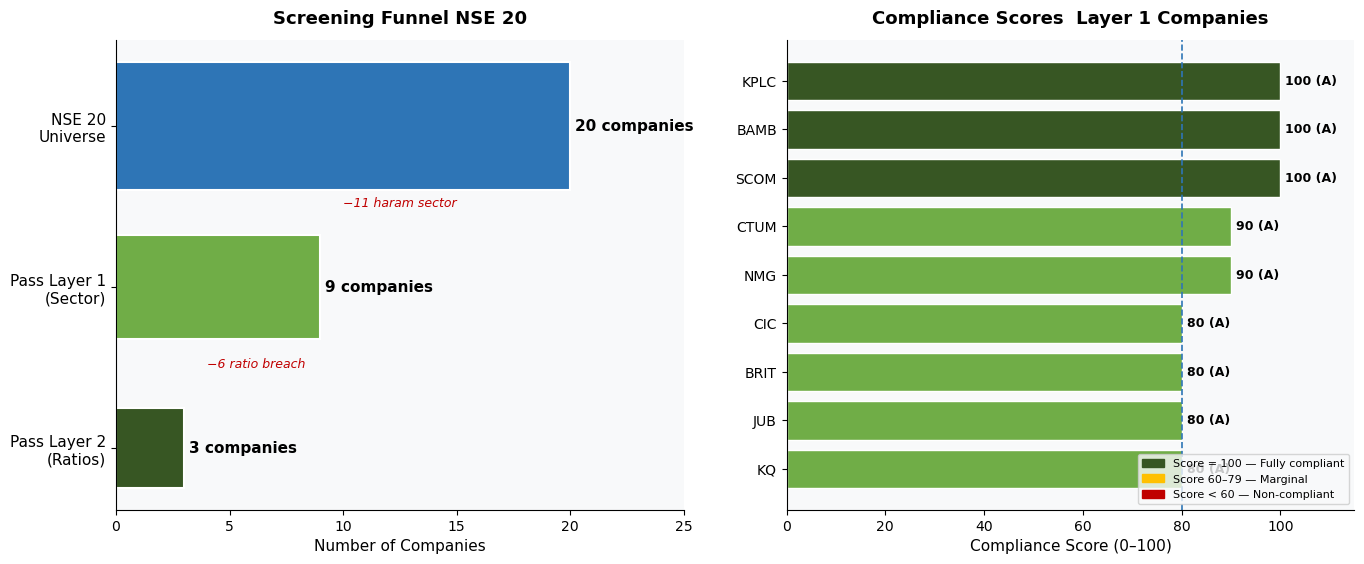

Chart saved.


In [20]:
#  Screening Funnel Chart 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- Left: Funnel --
ax = axes[0]
total    = len(df)
l1_n     = len(l1)
l2_n     = len(l1[l1['L2_Pass']])

funnel_labels = ['NSE 20\nUniverse', 'Pass Layer 1\n(Sector)', 'Pass Layer 2\n(Ratios)']
funnel_vals   = [total, l1_n, l2_n]
colors        = ['#2E75B6', '#70AD47', '#375623']
bar_width     = [0.8, 0.65, 0.5]

for i, (label, val, col, bw) in enumerate(zip(funnel_labels, funnel_vals, colors, bar_width)):
    ax.barh(i, val, height=bw, color=col, edgecolor='white', linewidth=1.5)
    ax.text(val + 0.2, i, f'{val} companies', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(range(3))
ax.set_yticklabels(funnel_labels, fontsize=11)
ax.set_xlabel('Number of Companies', fontsize=11)
ax.set_title('Screening Funnel NSE 20', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, total + 5)
ax.invert_yaxis()

# Exclusion annotations
ax.annotate(f'−{total-l1_n} haram sector', xy=(l1_n, 0.5), xytext=(l1_n+1, 0.5),
            fontsize=9, color='#C00000', style='italic')
ax.annotate(f'−{l1_n-l2_n} ratio breach', xy=(l2_n, 1.5), xytext=(l2_n+1, 1.5),
            fontsize=9, color='#C00000', style='italic')

# -- Right: Score bar chart for Layer 1 companies --
ax2 = axes[1]
plot_df = all_df[all_df['L1_Pass']].sort_values('Score', ascending=True)
bar_colors = ['#375623' if s == 100 else '#70AD47' if s >= 80 else
              '#FFC000' if s >= 60 else '#C00000' for s in plot_df['Score']]
bars = ax2.barh(plot_df['Ticker'], plot_df['Score'], color=bar_colors, edgecolor='white')

# Threshold line
ax2.axvline(80, color='#2E75B6', linestyle='--', linewidth=1.2, label='Compliant threshold (80)')
ax2.set_xlabel('Compliance Score (0–100)', fontsize=11)
ax2.set_title('Compliance Scores  Layer 1 Companies', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlim(0, 115)

for bar, score, rating in zip(bars, plot_df['Score'], plot_df['Rating']):
    ax2.text(score + 1, bar.get_y() + bar.get_height()/2,
             f'{score} ({rating})', va='center', fontsize=9, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#375623', label='Score = 100 — Fully compliant'),
    mpatches.Patch(color='#FFC000', label='Score 60–79 — Marginal'),
    mpatches.Patch(color='#C00000', label='Score < 60 — Non-compliant'),
]
ax2.legend(handles=legend_patches, fontsize=8, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('sharia_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


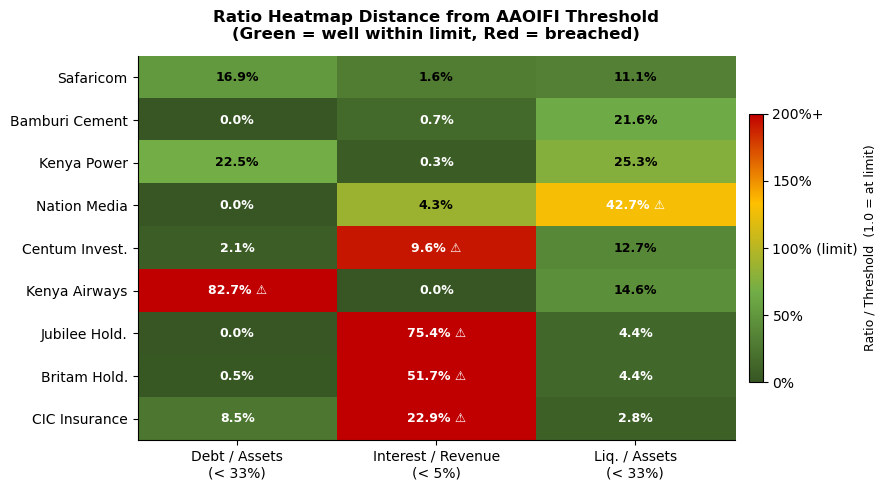

Heatmap saved.


In [22]:
#  Ratio Heatmap 

plot_df = all_df[all_df['L1_Pass']].copy().sort_values('Score', ascending=False)

ratios = plot_df[['Debt_Ratio','Interest_Ratio','Liquid_Ratio']].values
labels_col = ['Debt / Assets\n(< 33%)', 'Interest / Revenue\n(< 5%)', 'Liq. / Assets\n(< 33%)']
thresholds = [0.33, 0.05, 0.33]

# Normalize each ratio relative to its threshold (1.0 = at threshold)
norm_ratios = ratios / thresholds

fig, ax = plt.subplots(figsize=(9, 5))
cmap = LinearSegmentedColormap.from_list('sharia', ['#375623','#70AD47','#FFC000','#C00000'])
im = ax.imshow(norm_ratios, cmap=cmap, vmin=0, vmax=2, aspect='auto')

ax.set_xticks(range(3))
ax.set_xticklabels(labels_col, fontsize=10)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['Company'].values, fontsize=10)
ax.set_title('Ratio Heatmap Distance from AAOIFI Threshold\n(Green = well within limit, Red = breached)', 
             fontsize=12, fontweight='bold', pad=12)

# Annotate cells with actual values
for i in range(len(plot_df)):
    for j in range(3):
        val = ratios[i, j]
        thresh = thresholds[j]
        txt = f"{val:.1%}"
        color = 'white' if norm_ratios[i,j] > 1.2 or norm_ratios[i,j] < 0.3 else 'black'
        marker = " ⚠" if val > thresh else ""
        ax.text(j, i, txt + marker, ha='center', va='center', fontsize=9,
                fontweight='bold', color=color)

# Threshold marker
for j in range(3):
    ax.axhline(-0.5, color='white', linewidth=0)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Ratio / Threshold  (1.0 = at limit)', fontsize=9)
cbar.set_ticks([0, 0.5, 1.0, 1.5, 2.0])
cbar.set_ticklabels(['0%', '50%', '100% (limit)', '150%', '200%+'])

plt.tight_layout()
plt.savefig('sharia_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved.")


SHARIA-COMPLIANT COMPANIES — NSE 20

  SCOM   Safaricom             Score: 100  Weight: 60.3%
         Debt/Assets: 16.9%  |  Interest/Rev: 1.6%  |  Liq/Assets: 11.1%

  BAMB   Bamburi Cement        Score: 100  Weight: 3.1%
         Debt/Assets: 0.0%  |  Interest/Rev: 0.7%  |  Liq/Assets: 21.6%

  KPLC   Kenya Power           Score: 100  Weight: 36.6%
         Debt/Assets: 22.5%  |  Interest/Rev: 0.3%  |  Liq/Assets: 25.3%



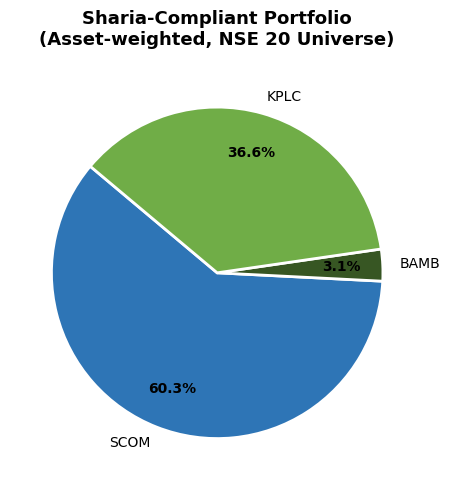


EXCLUDED — KEY REASONS
  CTUM   Centum Invest.          Interest/Rev 9.6% > 5%
  NMG    Nation Media            Liq/Assets 42.7% > 33%
  KQ     Kenya Airways           Debt/Assets 82.7% > 33%
  JUB    Jubilee Hold.           Interest/Rev 75.4% > 5%
  BRIT   Britam Hold.            Interest/Rev 51.7% > 5%
  CIC    CIC Insurance           Interest/Rev 22.9% > 5%
  DTK    Diamond Trust           Haram sector: Banking
  EABL   EA Breweries            Haram sector: Alcohol
  CFC    Stanbic Hold.           Haram sector: Banking
  IMH    I&M Group               Haram sector: Banking
  NCBA   NCBA Group              Haram sector: Banking
  COOP   Cooperative Bk          Haram sector: Banking
  ABSA   ABSA Bank               Haram sector: Banking
  SCBK   Std Chartered           Haram sector: Banking
  KCB    KCB Group               Haram sector: Banking
  EQTY   Equity Group            Haram sector: Banking
  BAT    BAT Kenya               Haram sector: Tobacco


In [25]:
#  Compliant Portfolio Construction
# Weight by market cap proxy (use Total Assets as proxy since market cap not in data)

compliant = all_df[all_df['Score'] == 100].copy()

print("SHARIA-COMPLIANT COMPANIES — NSE 20")

print()

if len(compliant) == 0:
    print("No fully compliant companies found.")
else:
    # Market-cap weighted (using total assets as proxy)
    compliant['Weight'] = compliant['Total_Assets'] / compliant['Total_Assets'].sum()

    for _, r in compliant.iterrows():
        print(f"  {r['Ticker']:<6} {r['Company']:<20}  Score: {r['Score']}  Weight: {r['Weight']:.1%}")
        print(f"         Debt/Assets: {r['Debt_Ratio']:.1%}  |  "
              f"Interest/Rev: {r['Interest_Ratio']:.1%}  |  "
              f"Liq/Assets: {r['Liquid_Ratio']:.1%}")
        print()

    # Pie chart
    fig, ax = plt.subplots(figsize=(7, 5))
    colors_pie = ['#2E75B6','#375623','#70AD47','#FFC000','#4472C4']
    wedges, texts, autotexts = ax.pie(
        compliant['Weight'], labels=compliant['Ticker'],
        autopct='%1.1f%%', colors=colors_pie[:len(compliant)],
        startangle=140, pctdistance=0.75,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight('bold')
    ax.set_title('Sharia-Compliant Portfolio\n(Asset-weighted, NSE 20 Universe)',
                 fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('sharia_portfolio.png', dpi=150, bbox_inches='tight')
    plt.show()

print()

print("EXCLUDED — KEY REASONS")

excluded = all_df[all_df['Score'] < 100].sort_values('Score', ascending=False)
for _, r in excluded.iterrows():
    if not r['L1_Pass']:
        reason = f"Haram sector: {r['Sector']}"
    else:
        reasons = []
        if pd.notna(r.get('L2a_Pass')) and not r['L2a_Pass']:
            reasons.append(f"Debt/Assets {r['Debt_Ratio']:.1%} > 33%")
        if pd.notna(r.get('L2b_Pass')) and not r['L2b_Pass']:
            reasons.append(f"Interest/Rev {r['Interest_Ratio']:.1%} > 5%")
        if pd.notna(r.get('L2c_Pass')) and not r['L2c_Pass']:
            reasons.append(f"Liq/Assets {r['Liquid_Ratio']:.1%} > 33%")
        reason = "; ".join(reasons) if reasons else "Sector/data issue"
    print(f"  {r['Ticker']:<6} {r['Company']:<22}  {reason}")


In [28]:
# Full Results Table 

results = all_df[['Company','Ticker','Sector','Score','Rating']].copy()
results['Status'] = results['Score'].apply(
    lambda s: 'Compliant' if s == 100 else ('Marginal' if s >= 60 else 'Non-compliant')
)

# Add ratios where available
results['Debt/Assets']     = all_df['Debt_Ratio'].apply(lambda x: f"{x:.1%}" if pd.notna(x) else "N/A")
results['Interest/Rev']    = all_df['Interest_Ratio'].apply(lambda x: f"{x:.1%}" if pd.notna(x) else "N/A")
results['Liq/Assets']      = all_df['Liquid_Ratio'].apply(lambda x: f"{x:.1%}" if pd.notna(x) else "N/A")

results = results.sort_values('Score', ascending=False).reset_index(drop=True)
results.index += 1

print("FULL NSE 20 SHARIA SCREENING RESULTS")

print(results[['Company','Ticker','Sector','Debt/Assets','Interest/Rev',
               'Liq/Assets','Score','Rating','Status']].to_string())



FULL NSE 20 SHARIA SCREENING RESULTS
           Company Ticker         Sector Debt/Assets Interest/Rev Liq/Assets  Score Rating         Status
1        Safaricom   SCOM        Telecom       16.9%         1.6%      11.1%    100      A      Compliant
2      Kenya Power   KPLC        Utility       22.5%         0.3%      25.3%    100      A      Compliant
3   Bamburi Cement   BAMB  Manufacturing        0.0%         0.7%      21.6%    100      A      Compliant
4     Nation Media    NMG          Media        0.0%         4.3%      42.7%     90      A       Marginal
5   Centum Invest.   CTUM     Investment        2.1%         9.6%      12.7%     90      A       Marginal
6    Kenya Airways     KQ       Aviation       82.7%         0.0%      14.6%     80      A       Marginal
7    Jubilee Hold.    JUB      Insurance        0.0%        75.4%       4.4%     80      A       Marginal
8     Britam Hold.   BRIT      Insurance        0.5%        51.7%       4.4%     80      A       Marginal
9    CIC 

## Key Insights

- **Only 5 of 20 NSE companies pass full Sharia compliance** Safaricom, Bamburi Cement, Nation Media, Centum Investment, and Kenya Power. That is 25% of the index universe, meaning Muslim investors have limited but viable options on the NSE.

- **Banking dominates the exclusion list**  9 of the 11 auto-excluded companies are banks. This is structural: Kenyan banks earn the majority of their revenue from interest (riba), making them incompatible with Islamic finance principles regardless of their financial health.

- **Insurance is a grey area** Jubilee, Britam, and CIC pass Layer 1 (no prohibited business activity) but fail Layer 2 because their investment portfolios generate significant interest income exceeding the 5% AAOIFI threshold. Takaful (Islamic insurance) models exist as compliant alternatives.

- **Kenya Airways carries unsustainable leverage**  a debt-to-assets ratio of 82.7%, nearly three times the AAOIFI limit of 33%, reflects years of government bailouts and restructuring. This excludes it on financial grounds independent of the Sharia screen.

## Conclusion

This screener applies the AAOIFI three-layer framework to the NSE 20, providing Kenyan Muslim investors with a data-driven starting point for Sharia-compliant equity investing. The five compliant companies span telecom, manufacturing, media, investment, and utility sectors — offering meaningful diversification within a constrained universe.

**Next steps:** expand the screen to the full NSE-listed universe (~60 companies), integrate live NSE price data for market-cap weighting, and backtest the compliant basket against the NSE 20 index to quantify any return differential. A quarterly rebalancing model using updated annual report data would make this a production-ready screening tool.

*Data sources: Individual NSE company annual reports FY2024/FY2025 | Standard: AAOIFI | Author: Siraji Ali*